In [1]:
from src.GA.ga_initialization import *
from src.GA.load_data_ga import load_data, load_output
from src.GA.ga_structures import Individual, Problem
from src.GA.ga_operators import *
from src.GA.ga_evolution_algorithm import run_genetic_algorithm
# from src.GA.lsv4 import local_search_softTW_first_improvement

ModuleNotFoundError: No module named 'src'

In [2]:
import numpy as np

In [3]:
# data = load_data('dataset_hustack/input/100.txt')
# best_solution = load_output('dataset_hustack/input/100.txt', 'dataset_hustack/output/100-bestSolution.txt')

In [4]:
data = load_data('dataset/hustack/input/200.txt')
best_solution = load_output('dataset/hustack/input/200.txt', 'dataset/hustack/output/200-bestSolution.txt')

In [5]:
problem = Problem(num_request=data[0],
                  request=data[1], 
                  time_matrix=np.array(data[2]))

In [6]:
best_solution.calObjective()
# print(best_solution.total_service_time)

np.float64(103560.0)

In [7]:
cal_std_fitness([best_solution])

In [8]:
print("---> Fittest individual: ", best_solution.fitness)
print("-----Corresponding to the best individual-----")
print("---> Route:",  best_solution.route)
print(sum(best_solution.route_computing[0]))
# Index 3: Total time (Scalar)
print("---> Total service time: ", best_solution.route_computing[3]) 

# Index 4: Lateness (List) -> dùng để đếm số lần vi phạm
print("Number of time window violations: ", sum(1 for x in best_solution.route_computing[4] if x != 0.0))

# Index 5: Total Lateness (Scalar)
print("Total time of late arrivals: ", best_solution.route_computing[5])

# Index 6: Wait (List) -> dùng để đếm số lần đến sớm
print("Number of arrivals ealier than opening time: ", sum(1 for x in best_solution.route_computing[6] if x != 0))

# Index 7: Total Wait (Scalar)
print("Total time of arrivals ealier than opening time:", best_solution.route_computing[7])

---> Fittest individual:  103560.0
-----Corresponding to the best individual-----
---> Route: [54, 92, 148, 4, 64, 149, 133, 126, 89, 86, 49, 142, 76, 105, 41, 162, 178, 39, 198, 98, 169, 195, 110, 100, 165, 193, 172, 163, 29, 6, 19, 189, 137, 34, 179, 67, 40, 157, 11, 158, 1, 108, 43, 174, 136, 93, 143, 48, 44, 182, 150, 197, 53, 97, 71, 102, 88, 138, 109, 16, 46, 183, 63, 69, 5, 130, 60, 3, 68, 166, 2, 171, 73, 116, 200, 127, 77, 177, 38, 140, 81, 160, 134, 84, 156, 164, 87, 57, 199, 90, 91, 117, 28, 94, 95, 112, 78, 188, 192, 21, 155, 120, 75, 14, 35, 83, 107, 196, 10, 52, 111, 118, 42, 151, 186, 167, 32, 51, 119, 170, 181, 122, 66, 194, 125, 132, 13, 9, 173, 8, 131, 61, 7, 185, 146, 70, 33, 103, 139, 82, 141, 129, 47, 22, 176, 135, 147, 36, 101, 45, 123, 25, 24, 154, 121, 15, 99, 153, 37, 144, 161, 96, 80, 59, 114, 56, 159, 17, 12, 106, 55, 65, 115, 152, 175, 20, 124, 168, 26, 31, 62, 50, 74, 184, 27, 113, 30, 79, 187, 190, 191, 128, 58, 85, 104, 180, 145, 72, 23, 18]
97720
---> To

In [9]:
# gen_type = 'random'
# gen_type = 'greedy'
pop_size = 100
c_rate = 0.8
m_rate = 0.2
generations = 300
maximum_loop = 100

In [10]:
params ={
    # "fmethod": 'std', # std, ranking, distribution
    # "fmethod": 'ranking', # std, ranking, distribution
    # "fmethod": 'distribution', # std, ranking, distribution
    # "smethod": 'tournament', # tournament, roulette, random, ranking
    "smethod": 'roulette', # tournament, roulette, random, ranking
    "cmethod": 'ox', # ox, pmx, cx
    # "mmethod": 'inversion', # inversion, swap, scramble
    # "mmethod": 'scramble', # inversion, swap, scramble
    "mmethod": 'swap', # inversion, swap, scramble
    # "svmethod": 'tournament', # tournament, truncation, sus, linear
    "svmethod": 'sus', # tournament, truncation, sus, linear
    
    # "ranking_f_parameter": 0.5, # dùng cho ranking trong calculate_fitness
    
    "tourn_s_parameter": 4, # dùng cho tournament trong select_parents
    "ranking_s_parameter": 3, # dùng cho ranking trong select_parents
    
    "trunc_sv_parameter": 0.5, # dùng cho truncation trong apply_sv_selection
    # "linear_sv_parameter": 1.5, # dùng cho linear trong apply_sv_selection
    "tourn_sv_parameter": 4, # dùng cho tournament trong apply_sv_selection
    
    "gen_type": 'greedy', # loại khởi tạo greedy
    "greedy_rate": 0.5, # tỉ lệ các cá thể được khởi tạo greedy trong quần thể ban đầu
    "search_size": 2, # số lượng hàng xóm xét tại mỗi điểm đang đứng mà sẽ lựa chọn một trong số chúng để đến trong lộ trình tham lam
    
    # "imp_type": 'first_improvement',
    "ls_rate" : 0.1,
    "max_iter" : 10
}

In [11]:
last_pop = run_genetic_algorithm(problem, pop_size, c_rate, m_rate, generations, maximum_loop, **params)


Initial fitness:  3222714580.0
Gen 0: Fit=3078258820 | Mut=inversion | Sel=roulette | Surv=sus
Gen 20: Fit=2328487860 | Mut=inversion | Sel=roulette | Surv=sus
Gen 40: Fit=1847402110 | Mut=inversion | Sel=roulette | Surv=sus
Gen 60: Fit=1704041070 | Mut=inversion | Sel=roulette | Surv=sus
Gen 80: Fit=1402295300 | Mut=inversion | Sel=roulette | Surv=sus
Gen 100: Fit=1258347640 | Mut=inversion | Sel=tournament | Surv=sus
Gen 120: Fit=1111007380 | Mut=scramble | Sel=tournament | Surv=tournament
Gen 140: Fit=909407380 | Mut=scramble | Sel=tournament | Surv=tournament
Gen 160: Fit=653362540 | Mut=scramble | Sel=tournament | Surv=tournament
Gen 180: Fit=472915300 | Mut=scramble | Sel=tournament | Surv=tournament
Gen 200: Fit=283304490 | Mut=scramble | Sel=tournament | Surv=tournament
Gen 220: Fit=151312580 | Mut=scramble | Sel=tournament | Surv=tournament
Gen 240: Fit=59509340 | Mut=swap | Sel=tournament | Surv=tournament
Gen 260: Fit=16367420 | Mut=swap | Sel=tournament | Surv=tournament
Ge

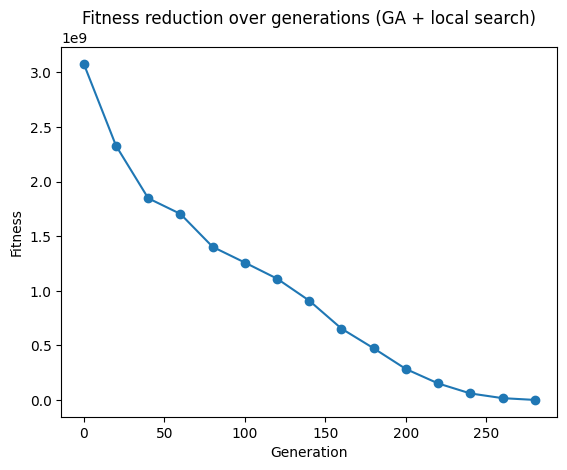

In [1]:
import matplotlib.pyplot as plt

# Data extracted from the log
generations = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280]
fitness = [
    3078258820, 2328487860, 1847402110, 1704041070, 1402295300,
    1258347640, 1111007380, 909407380, 653362540, 472915300,
    283304490, 151312580, 59509340, 16367420, 103560
]

plt.figure()
plt.plot(generations, fitness, marker='o')
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("Fitness reduction over generations (GA + local search)")
plt.show()


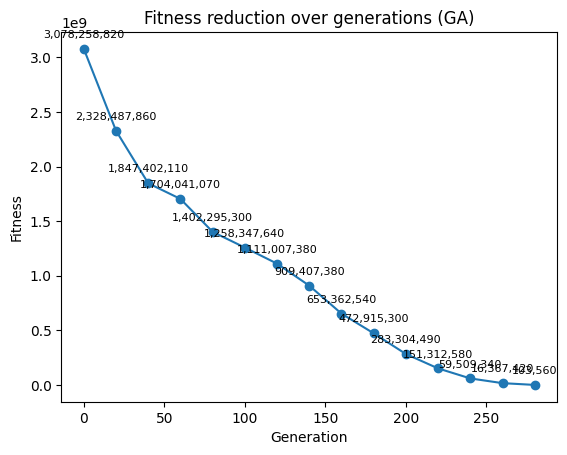

In [ ]:
# import matplotlib.pyplot as plt

# # Data from GA log
# generations = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280]
# fitness = [
#     3078258820, 2328487860, 1847402110, 1704041070, 1402295300,
#     1258347640, 1111007380, 909407380, 653362540, 472915300,
#     283304490, 151312580, 59509340, 16367420, 103560
# ]

# plt.figure()
# plt.plot(generations, fitness, marker='o')
# plt.xlabel("Generation")
# plt.ylabel("Fitness")
# plt.title("Fitness reduction over generations (GA)")

# # Annotate each point with fitness value
# for x, y in zip(generations, fitness):
#     plt.annotate(f"{y:,}", (x, y), textcoords="offset points", xytext=(0,8), ha='center', fontsize=8)

# plt.show()
